# 0. document and nodes identification

In [1]:
import pandas as pd

# 读取文本文件
with open(r'C:\Users\owner\Desktop\KG\OneNYC_2050_Strategic_Plan_final.txt', 'r', encoding='utf-8') as file:
    documents = file.readlines()

# 简单预处理（移除空行）
documents = [doc.strip() for doc in documents if doc.strip()]

fixed_nodes_list = {
    'resilience',
    'adaptive capacity',
    'vulnerability assessment',
    'climate proofing',
    'ecosystem-based adaptation',
    'zoning',
    'land use planning',
    'urban design',
    'transportation planning',
    'sustainable development'
}

# model - multilingual-e5-large-instruct
https://huggingface.co/intfloat/multilingual-e5-large-instruct

In [ ]:
import os
os.environ['HF_TOKEN'] = '' # this is your Hugging Face token, you can get it from https://huggingface.co/settings/tokens

In [3]:
import os
from huggingface_hub import InferenceClient
client = InferenceClient(
    provider="auto",
    api_key=os.environ['HF_TOKEN'],
)

result = client.feature_extraction(
    "Today is a sunny day and I will get some ice cream.",
    model="intfloat/multilingual-e5-large-instruct",
)

In [4]:
# 1) Load tokenizer & model
from transformers import AutoTokenizer, AutoModel # 换成 Auto* 更通用
import torch

# 重点：替换模型 ID
MODEL_ID = "intfloat/multilingual-e5-large-instruct" 
    
# Qwen 模型需要启用 trust_remote_code=True
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model     = AutoModel.from_pretrained(MODEL_ID, trust_remote_code=True)
model.eval() 
# 如果你想强制使用 CPU（推荐，防止出现你之前遇到的 DLL 错误）
DEVICE = "cpu"
model.to(DEVICE)

XLMRobertaModel(
  (embeddings): XLMRobertaEmbeddings(
    (word_embeddings): Embedding(250002, 1024, padding_idx=1)
    (position_embeddings): Embedding(514, 1024, padding_idx=1)
    (token_type_embeddings): Embedding(1, 1024)
    (LayerNorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): XLMRobertaEncoder(
    (layer): ModuleList(
      (0-23): 24 x XLMRobertaLayer(
        (attention): XLMRobertaAttention(
          (self): XLMRobertaSdpaSelfAttention(
            (query): Linear(in_features=1024, out_features=1024, bias=True)
            (key): Linear(in_features=1024, out_features=1024, bias=True)
            (value): Linear(in_features=1024, out_features=1024, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): XLMRobertaSelfOutput(
            (dense): Linear(in_features=1024, out_features=1024, bias=True)
            (LayerNorm): LayerNorm((1024,), eps=1e-05, eleme

Transformers Usage


In [5]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
model = SentenceTransformer(
    "intfloat/multilingual-e5-large-instruct",
    device="cpu"  
)
sentence_embeddings = model.encode(
    documents,
    batch_size=8,
    normalize_embeddings=True,
    show_progress_bar=True
)

fixed_nodes_embeddings = model.encode(
    list(fixed_nodes_list),
    batch_size=8,
    normalize_embeddings=True,
    show_progress_bar=True
)
# Node weights: Fixed nodes vs sentences
similarity_matrix_nodes_sentences = cosine_similarity(
    fixed_nodes_embeddings,
    sentence_embeddings
)
node_weights = similarity_matrix_nodes_sentences.mean(axis=1)

# Edge weights: Fixed nodes vs fixed nodes
edge_similarity_matrix = cosine_similarity(fixed_nodes_embeddings)

print("Node Weights:", node_weights)
print("Edge Similarity Matrix:", edge_similarity_matrix)

Batches:   0%|          | 0/58 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Node Weights: [0.7409201  0.74570525 0.7224849  0.74383706 0.7370816  0.73281944
 0.7379554  0.73150796 0.73006076 0.73834085]
Edge Similarity Matrix: [[0.99999976 0.8915542  0.90123266 0.90286434 0.88798267 0.85578966
  0.8688817  0.8979509  0.8694931  0.8723657 ]
 [0.8915542  1.         0.8588218  0.89333904 0.93194646 0.84554255
  0.92559975 0.8482236  0.8483887  0.915653  ]
 [0.90123266 0.8588218  1.0000002  0.9025765  0.8739624  0.863527
  0.8558203  0.89972556 0.9313264  0.8561818 ]
 [0.90286434 0.89333904 0.9025765  1.0000005  0.88125205 0.8832518
  0.8834268  0.90259707 0.8973751  0.88065946]
 [0.88798267 0.93194646 0.8739624  0.88125205 1.         0.8569669
  0.93531674 0.83259284 0.8519596  0.92208624]
 [0.85578966 0.84554255 0.863527   0.8832518  0.8569669  0.99999994
  0.86055875 0.89813757 0.8915489  0.85728395]
 [0.8688817  0.92559975 0.8558203  0.8834268  0.93531674 0.86055875
  1.0000004  0.84506714 0.855817   0.8973576 ]
 [0.8979509  0.8482236  0.89972556 0.90259707 0.

In [6]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
# 假设您已导入 SentenceTransformer 并定义了 model, documents, fixed_nodes_list


# 2. 初始相似度矩阵
# sim_matrix: 固定节点（行） vs 句子（列）
sim_matrix = cosine_similarity(
    fixed_nodes_embeddings,
    sentence_embeddings
)

# ----------------------------------------------------
# --- 阶段二：边权重融合逻辑 (核心集成部分) ---
# ----------------------------------------------------

# 映射变量名以符合融合逻辑的定义
concept_embeddings = fixed_nodes_embeddings
concepts = list(fixed_nodes_list)

# 参数设置 (您可以调整这些超参数)
threshold = 0.3  # 相似度阈值
alpha = 0.5      # 共现强度的权重
beta  = 0.5      # 语义相似的权重

n_concepts = sim_matrix.shape[0] # n_concepts 是 fixed_nodes 的数量
# n_topics = sim_matrix.shape[1] # n_topics 是句子的数量

# 1. 计算概念–句子的“出现掩码”：
presence = (sim_matrix >= threshold).astype(int)  # shape (n_concepts, n_sentences), 使用astype(int)方便矩阵乘法

# 2. 共现计数：【优化：使用矩阵乘法进行高效计算】
# co_counts = presence @ presence.T 
# 注意：在您的原始逻辑中，sim_matrix 是 n_concepts x n_topics。
# co_counts[i, j] 统计 i 和 j 共同出现在多少个 topic/sentence 中。
# 矩阵乘法：(n_concepts x n_sentences) @ (n_sentences x n_concepts) -> (n_concepts x n_concepts)
co_counts = presence @ presence.T

# 3. 归一化共现得分到 [0,1]
max_co = co_counts.max() if co_counts.max() > 0 else 1.0
co_norm = co_counts / max_co

# 4. 计算概念间语义相似度（余弦）
sem_sim = cosine_similarity(concept_embeddings)  # shape (n_concepts, n_concepts)

# 5. 融合：alpha·共现 + beta·语义
edge_raw = alpha * co_norm + beta * sem_sim

# Min–Max 归一化函数
def minmax_norm_mat(mat):
    mn, mx = mat.min(), mat.max()
    if mx > mn:
        return (mat - mn) / (mx - mn)
    else:
        return np.zeros_like(mat)

edge_weights = minmax_norm_mat(edge_raw)

print("--- 融合边权重计算结果 ---")
print("最终边权重矩阵维度:", edge_weights.shape)
print("部分边权重示例 (Concept-Concept):")
print(edge_weights)


--- 融合边权重计算结果 ---
最终边权重矩阵维度: (10, 10)
部分边权重示例 (Concept-Concept):
[[0.99999573 0.35220217 0.41001604 0.41976277 0.33086796 0.13856487
  0.21676943 0.39041256 0.22042174 0.23758097]
 [0.35220217 0.99999715 0.15667723 0.36286394 0.59348317 0.07735433
  0.5555715  0.09336959 0.09435548 0.49615507]
 [0.41001604 0.15667723 0.99999858 0.41804343 0.24711871 0.18478342
  0.13874788 0.40101345 0.58977923 0.14090729]
 [0.41976277 0.36286394 0.41804343 1.         0.29066301 0.30260831
  0.30365366 0.41816627 0.38697317 0.28712321]
 [0.33086796 0.59348317 0.24711871 0.29066301 0.99999715 0.14559711
  0.61361537 0.         0.11568613 0.53458372]
 [0.13856487 0.07735433 0.18478342 0.30260831 0.14559711 0.9999968
  0.16705274 0.3915277  0.35217049 0.14749092]
 [0.21676943 0.5555715  0.13874788 0.30365366 0.61361537 0.16705274
  0.99999929 0.07451451 0.13872829 0.38686849]
 [0.39041256 0.09336959 0.40101345 0.41816627 0.         0.3915277
  0.07451451 0.99999715 0.50579962 0.04175197]
 [0.22042174 0.09

In [7]:
edge_similarity_matrix

array([[0.99999976, 0.8915542 , 0.90123266, 0.90286434, 0.88798267,
        0.85578966, 0.8688817 , 0.8979509 , 0.8694931 , 0.8723657 ],
       [0.8915542 , 1.        , 0.8588218 , 0.89333904, 0.93194646,
        0.84554255, 0.92559975, 0.8482236 , 0.8483887 , 0.915653  ],
       [0.90123266, 0.8588218 , 1.0000002 , 0.9025765 , 0.8739624 ,
        0.863527  , 0.8558203 , 0.89972556, 0.9313264 , 0.8561818 ],
       [0.90286434, 0.89333904, 0.9025765 , 1.0000005 , 0.88125205,
        0.8832518 , 0.8834268 , 0.90259707, 0.8973751 , 0.88065946],
       [0.88798267, 0.93194646, 0.8739624 , 0.88125205, 1.        ,
        0.8569669 , 0.93531674, 0.83259284, 0.8519596 , 0.92208624],
       [0.85578966, 0.84554255, 0.863527  , 0.8832518 , 0.8569669 ,
        0.99999994, 0.86055875, 0.89813757, 0.8915489 , 0.85728395],
       [0.8688817 , 0.92559975, 0.8558203 , 0.8834268 , 0.93531674,
        0.86055875, 1.0000004 , 0.84506714, 0.855817  , 0.8973576 ],
       [0.8979509 , 0.8482236 , 0.8997255

In [ ]:
# --- 修正后的保存代码 ---
save_dir = "e5_embedding_results/"
import os
os.makedirs(save_dir, exist_ok=True) 
city = 'NYC' 

# 1. 保存嵌入向量 (保持不变)
np.save(os.path.join(save_dir, f'sentence_embeddings_{city}.npy'), sentence_embeddings)
np.save(os.path.join(save_dir, f'fixed_nodes_embeddings_{city}.npy'), fixed_nodes_embeddings)

# 2. 保存计算结果
np.save(os.path.join(save_dir, f'similarity_matrix_nodes_sentences_{city}.npy'), similarity_matrix_nodes_sentences)
np.save(os.path.join(save_dir, f'node_weights_{city}.npy'), node_weights)
# 【移除】np.save(os.path.join(save_dir, f'edge_similarity_matrix_{city}.npy'), edge_similarity_matrix) 
# 【新增/替换】保存您的融合边权重结果
np.save(os.path.join(save_dir, f'fused_edge_weights_{city}.npy'), edge_weights) 

print(f"所有结果已保存到 {save_dir} 目录下，城市标识: {city}。")


所有结果已保存到 e5_embedding_results/ 目录下，城市标识: NYC。
加载成功！所有结果已为城市 NYC 准备就绪。


In [1]:

import numpy as np
import os
city = 'NYC' 
load_dir = "e5_embedding_results/"

# 检查所有必需的文件是否存在
required_files = [
    f'sentence_embeddings_{city}.npy', 
    f'fixed_nodes_embeddings_{city}.npy',
    f'node_weights_{city}.npy',
    # 【移除检查】f'edge_similarity_matrix_{city}.npy',
    f'fused_edge_weights_{city}.npy' # 【检查新的融合权重】
]

all_files_exist = all(os.path.exists(os.path.join(load_dir, f)) for f in required_files)

if all_files_exist:
    # 加载嵌入向量
    sentence_embeddings = np.load(os.path.join(load_dir, f'sentence_embeddings_{city}.npy'))
    fixed_nodes_embeddings = np.load(os.path.join(load_dir, f'fixed_nodes_embeddings_{city}.npy'))

    # 加载计算结果
    node_weights = np.load(os.path.join(load_dir, f'node_weights_{city}.npy'))
    # 【移除】edge_similarity_matrix = np.load(os.path.join(load_dir, f'edge_similarity_matrix_{city}.npy'))
    
    # 【新增】加载您的融合边权重结果
    edge_weights = np.load(os.path.join(load_dir, f'fused_edge_weights_{city}.npy')) 

    print(f"加载成功！所有结果已为城市 {city} 准备就绪。")

加载成功！所有结果已为城市 NYC 准备就绪。


In [17]:
# 1. 准备概念列表
fixed_nodes_list = [
    'resilience',
    'adaptive capacity',
    'vulnerability assessment',
    'climate proofing',
    'ecosystem-based adaptation',
    'zoning',
    'land use planning',
    'urban design',
    'transportation planning',
    'sustainable development'
]
concepts = fixed_nodes_list   # 转成有序列表
topic_weights = dict(zip(concepts, node_weights))
topic_weights


{'resilience': 0.7409201,
 'adaptive capacity': 0.74570525,
 'vulnerability assessment': 0.7224849,
 'climate proofing': 0.74383706,
 'ecosystem-based adaptation': 0.7370816,
 'zoning': 0.73281944,
 'land use planning': 0.7379554,
 'urban design': 0.73150796,
 'transportation planning': 0.73006076,
 'sustainable development': 0.73834085}

In [18]:

# --- 阶段三：结果处理（可选，用于绘图或分析）---
import pandas as pd

# 展平成 DataFrame 的长格式（用于 NetworkX 绘图的边列表）
rows = []
for i in range(n_concepts):
    for j in range(i + 1, n_concepts): # 只需要上半三角
        rows.append({
            'Source': concepts[i],
            'Target': concepts[j],
            'Weight': edge_weights[i, j],
        })
df_edges = pd.DataFrame(rows)

# 打印前几行
print("\n--- 边列表 DataFrame (用于构建图) ---")
print(df_edges)


--- 边列表 DataFrame (用于构建图) ---
                        Source                      Target    Weight
0                   resilience           adaptive capacity  0.352202
1                   resilience    vulnerability assessment  0.410016
2                   resilience            climate proofing  0.419763
3                   resilience  ecosystem-based adaptation  0.330868
4                   resilience                      zoning  0.138565
5                   resilience           land use planning  0.216769
6                   resilience                urban design  0.390413
7                   resilience     transportation planning  0.220422
8                   resilience     sustainable development  0.237581
9            adaptive capacity    vulnerability assessment  0.156677
10           adaptive capacity            climate proofing  0.362864
11           adaptive capacity  ecosystem-based adaptation  0.593483
12           adaptive capacity                      zoning  0.077354
13 

In [19]:
# 在绘制节点时，提取每个节点对应的大小
sizes = [topic_weights[node] for node in topic_weights]
sizes

[0.7409201,
 0.74570525,
 0.7224849,
 0.74383706,
 0.7370816,
 0.73281944,
 0.7379554,
 0.73150796,
 0.73006076,
 0.73834085]

In [20]:
fixed_nodes_list

['resilience',
 'adaptive capacity',
 'vulnerability assessment',
 'climate proofing',
 'ecosystem-based adaptation',
 'zoning',
 'land use planning',
 'urban design',
 'transportation planning',
 'sustainable development']

In [21]:
import pandas as pd


frequent_itemsets = []
# 遍历 DataFrame 的每一行
for row in df_edges.itertuples():
    # row.Source 和 row.Target 组成一个元组作为 itemset
    itemset_tuple = (row.Source, row.Target)
    
    # 将 ((Source, Target), Weight) 格式的元组添加到列表中
    frequent_itemsets.append((itemset_tuple, row.Weight))


In [14]:
frequent_itemsets

[(('resilience', 'adaptive capacity'), 0.35220217372573287),
 (('resilience', 'vulnerability assessment'), 0.4100160433862155),
 (('resilience', 'climate proofing'), 0.4197627743593505),
 (('resilience', 'ecosystem-based adaptation'), 0.33086795929978774),
 (('resilience', 'zoning'), 0.13856486818859276),
 (('resilience', 'land use planning'), 0.21676943311232436),
 (('resilience', 'urban design'), 0.3904125635451255),
 (('resilience', 'transportation planning'), 0.22042174238437617),
 (('resilience', 'sustainable development'), 0.23758097352663252),
 (('adaptive capacity', 'vulnerability assessment'), 0.15667723170765574),
 (('adaptive capacity', 'climate proofing'), 0.3628639402641996),
 (('adaptive capacity', 'ecosystem-based adaptation'), 0.5934831665500025),
 (('adaptive capacity', 'zoning'), 0.07735432954240389),
 (('adaptive capacity', 'land use planning'), 0.5555714984579693),
 (('adaptive capacity', 'urban design'), 0.093369588205512),
 (('adaptive capacity', 'transportation p

Updated edge widths (non-zero):  [0.35220217372573287, 0.4100160433862155, 0.4197627743593505, 0.33086795929978774, 0.13856486818859276, 0.21676943311232436, 0.3904125635451255, 0.22042174238437617, 0.23758097352663252, 0.15667723170765574, 0.3628639402641996, 0.5934831665500025, 0.07735432954240389, 0.5555714984579693, 0.093369588205512, 0.09435547671928773, 0.49615507040077134, 0.4180434332134411, 0.24711870610410613, 0.18478342140699003, 0.1387478753016591, 0.4010134463942258, 0.5897792307577278, 0.14090728802684863, 0.2906630055749521, 0.3026083142196527, 0.3036536622429266, 0.41816626872707513, 0.38697316916337265, 0.2871232065124897, 0.1455971123328992, 0.6136153731671695, 0.11568613069556233, 0.5345837157849688, 0.16705273809261015, 0.39152769638194224, 0.35217048572366494, 0.14749091551266558, 0.07451451488517194, 0.13872829282847107, 0.38686849194305845, 0.5057996164683615, 0.041751969106690295, 0.1755180632293136]
sizes:[0.7409201, 0.74570525, 0.7224849, 0.74383706, 0.7370816

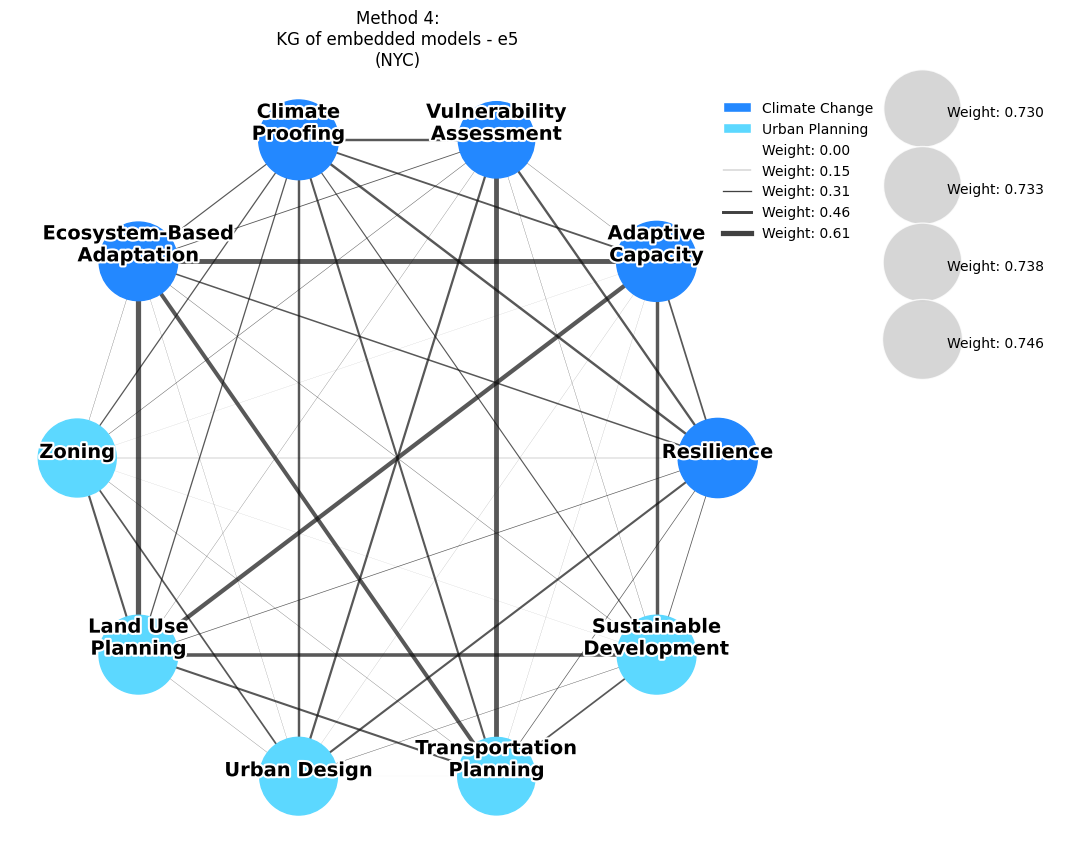

In [22]:
import textwrap
import networkx as nx
import matplotlib.patheffects as path_effects
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt

# 根据频繁项集构建共现关系图
G = nx.Graph()

# 1. 添加所有节点
for topic in topic_weights:
    G.add_node(topic)

# 2. 添加所有边
for (u, v), freq in frequent_itemsets:
    G.add_edge(u, v, weight=freq)

# 3. （可选）按节点大小阈值来剔除部分边
threshold = 0.0001
for node, size in zip(topic_weights.keys(), sizes):
    if np.isnan(size) or size < threshold:
        for neigh in list(G.neighbors(node)):
            G.remove_edge(node, neigh)

# 4. 获取剩余边并绘制
edges = list(G.edges(data=True))
edge_widths = [data['weight'] for _, _, data in edges if data['weight'] > 0]

# 打印更新后的边宽度
print("Updated edge widths (non-zero): ", edge_widths)

# 圆形布局
pos = nx.circular_layout(G)  # 使用圆形布局
np.random.seed(42)
plt.figure(figsize=(10, 10))
k=8000
j=10
constant = 0

###############
#####Nodes#####
###############
# 绘制前五个固定节点（深蓝色，中心较大）
nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=list(fixed_nodes_list)[:5],  # 前五个节点
    node_color="#2388FF",
    node_size=[(constant + (size**3) * k) for size in sizes[:5]],  # 计算前五个节点的大小
    label="climate adaptation"
)
# 绘制剩余的固定节点（浅蓝色，中心较大）
nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=list(fixed_nodes_list)[5:],  # 剩余节点
    node_color="#5CD8FF",
    node_size=[(constant + (size**3) * k) for size in sizes[5:]],  # 计算剩余节点的大小
    label="urban planning"
)
print(f'sizes:{sizes}')
###############

###############
######Edge#####
###############
# 绘制权重大于0的边
nx.draw_networkx_edges(
    G,
    pos,
    width=[edge_width**2 * j for edge_width in edge_widths if edge_width >= 0.001],  # 使用非零的边宽
    edge_color='#111111',
    alpha=0.7,
)
###############

# 提取边的权重
edges1 = G.edges(data=True)
weights1 = [data['weight'] for _, _, data in edges1]

# 生成用于图例的示例边权重
min_weight, max_weight = min(weights1), max(weights1)

# 不再归一化，直接使用原始权重
# 此时 example_widths 和 example_weights 均为有效的范围

example_weights = [
    min_weight,
    min_weight + (max_weight - min_weight) / 4,
    min_weight + (max_weight - min_weight) / 2,
    min_weight + (max_weight - min_weight) / 4 * 3,
    max_weight
]

example_widths = [
    min_weight**2 * j,
    ((min_weight + (max_weight - min_weight) /4 )**2) * j,
    ((min_weight + (max_weight - min_weight) / 2)**2) * j,
    ((min_weight + (max_weight - min_weight) / 4 * 3 )**2) * j,
    max_weight**2 * j
]


# 绘制标签并首字母大写，添加白色描边
for node, (x, y) in pos.items():
    weight = f"{topic_weights.get(node, 0):.4f}" if topic_weights.get(node, 0) > 0 else "0"
    modified_node = f"{node}"#\n{weight}
    wrapped_text = textwrap.fill(modified_node.title(), width=15)
    text = plt.text(
        x, y, wrapped_text, fontsize=14, fontweight='bold', ha='center', color='black'
    )
    text.set_path_effects([
        path_effects.Stroke(linewidth=3, foreground='white'),  # 添加白色描边
        path_effects.Normal()  # 恢复正常文字效果
    ])


# 添加图例
legend_elements = [
    Patch(facecolor='#2388FF', edgecolor='#ffffff', label='Climate Change'),  # 蓝色固定节点
    Patch(facecolor='#5CD8FF', edgecolor='#ffffff', label='Urban Planning'),   # 黄色固定节点
]
# 调整图例中的节点大小计算
legend_node_sizes = [ np.sqrt(constant +(size**3)*k) for size in sizes]  # 图例中的圆圈大小通常是基于半径或直径来设置的，但 NetworkX 的 node_size 参数是基于面积的。
legend_node_weights = [topic_weights for topic_weights in sizes]

# 对节点权重和大小去重并排序，同时移除 NaN
unique_weights_sizes = sorted(
    {(w, s) for w, s in zip(legend_node_weights, legend_node_sizes) if not np.isnan(w) and not np.isnan(s)}
)
sorted_weights, sorted_sizes = zip(*unique_weights_sizes) if unique_weights_sizes else ([], [])

# 限制图例中最多五个节点，确保头尾都在
max_legend_items = 5

if len(sorted_weights) > max_legend_items:
    # 包含头尾节点
    first_weight, last_weight = sorted_weights[0], sorted_weights[-1]
    first_size, last_size = sorted_sizes[0], sorted_sizes[-1]

    # 从中间节点中等间距选取剩余的节点
    middle_weights = sorted_weights[1:-1]
    middle_sizes = sorted_sizes[1:-1]
    num_middle_items = max_legend_items - 2  # 除去头尾的数量

    if num_middle_items > 0:
        step = max(1, len(middle_weights) // num_middle_items)  # 计算步长
        sampled_indices = list(range(0, len(middle_weights), step))[:num_middle_items]
        middle_weights = [middle_weights[i] for i in sampled_indices]
        middle_sizes = [middle_sizes[i] for i in sampled_indices]
    else:
        middle_weights, middle_sizes = [], []

    # 合并头部、中间和尾部
    sorted_weights =  middle_weights + [last_weight]
    sorted_sizes =  middle_sizes + [last_size]

# 添加边权重示例
for w, width in zip(example_weights[:], example_widths[:]):
    legend_elements.append(
        Line2D(
            [0], [0],
            color='#111111',
            alpha=0.8,
            lw=width,
            label=f"Weight: {w:.2f}"
        )
    )

# 添加节点大小图例
node_size_legend = [
    Line2D([0], [0], marker='o', color='w',
           markersize=size,  # 直接使用调整后的半径作为markersize
           markerfacecolor='#CCCCCC',
           alpha=0.8,
           label=f"Weight: {weight:.3f}")
    for weight, size in zip(sorted_weights, sorted_sizes)
]
legend_elements.extend(node_size_legend)

# 绘制节点图例
node_legend = plt.legend(
    handles=legend_elements[:7],  # 节点相关图例
    loc="upper right",
    bbox_to_anchor=(1.15, 1),
    fontsize=10,
    #labelspacing=1.2,
    frameon=False,
    borderpad=1.5    # 增加边框和内容之间的填充
)
plt.gca().add_artist(node_legend)  # 手动添加第一个图例
# 绘制边权重图例
plt.legend(
    handles=legend_elements[7:],  # 边权重相关图例
    loc="upper right",
    bbox_to_anchor=(1.37, 1),
    fontsize=10,
    frameon=False,
    labelspacing=4,  #1.2 # 增加标签之间的垂直间距
    handleheight=2,    # 增加句柄（marker）高度
    borderpad=1.5      # 增加边框和内容之间的填充
)
plt.title("Method 4:\n KG of embedded models - e5 \n(NYC)")
plt.axis('off')
plt.show()

In [2]:
import numpy as np   
np.std(node_weights)
print(np.std(node_weights))
np.max(node_weights) - np.min(node_weights)
print(np.max(node_weights) - np.min(node_weights))

0.0066216947
0.02322036
